<a href="https://colab.research.google.com/github/davidlealo/tarea_1_sisrec_2026/blob/main/TAREA_1_SICREC_G26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 1 Sistemas de Recomendación
### Tarea 26


*   Marcelo Vargas
*   David Leal





In [2]:
import pandas as pd
import numpy as np
import requests
from io import BytesIO

# Variable para URLs
BASE_URL = "https://raw.githubusercontent.com/davidlealo/tarea_1_sisrec_2026/main/data/"

def get_url(file_name):
    return f"{BASE_URL}{file_name}"


df_train_music = pd.read_csv(get_url("ydata_train.txt"), sep='\t',
                             names=['user_id', 'artist_id', 'rating'], header=None)
df_val_music = pd.read_csv(get_url("ydata_val.txt"), sep='\t',
                           names=['user_id', 'artist_id', 'rating'], header=None)
df_artists = pd.read_csv(get_url("ydata_artists.txt"), sep='\t',
                         names=['artist_id', 'artist_name', 'genre'], header=None)

df_train_wiki = pd.read_csv(get_url("wikimedia_train.csv"))
df_val_wiki = pd.read_csv(get_url("wikimedia_validation.csv"))


def load_remote_npy(file_name):
    response = requests.get(get_url(file_name))
    return np.load(BytesIO(response.content), allow_pickle=True)

image_embeddings = load_remote_npy("wikimedia_image_embeddings.npy")
item_id_to_idx = load_remote_npy("wikimedia_item_id_to_idx.npy").item()

print("¡Datos cargados exitosamente!")

¡Datos cargados exitosamente!


## Análisis del set de datos: `df_artists`
Para analizar esto analizaré primero la cantidad de artístas únicos y géneros únicos, además de contar la cantidad de géneros distintos


In [28]:
artistas_unicos = df_artists['artist_id'].nunique()
print("Cantidad de artistas únicos:", artistas_unicos)

Cantidad de artistas únicos: 2631


In [29]:
generos_musicales_unicos = df_artists['genre'].nunique()
print("Cantidad de géneros únicos:", generos_musicales_unicos)

Cantidad de géneros únicos: 15


In [30]:
generos_musicales = df_artists['genre'].value_counts()
generos_musicales

,count
genre,
rock,773
electronic,693
pop,244
folk,222
country,177
punk,145
metal,107
hiphop,68
jazz,51


In [32]:
import matplotlib.pyplot as plt

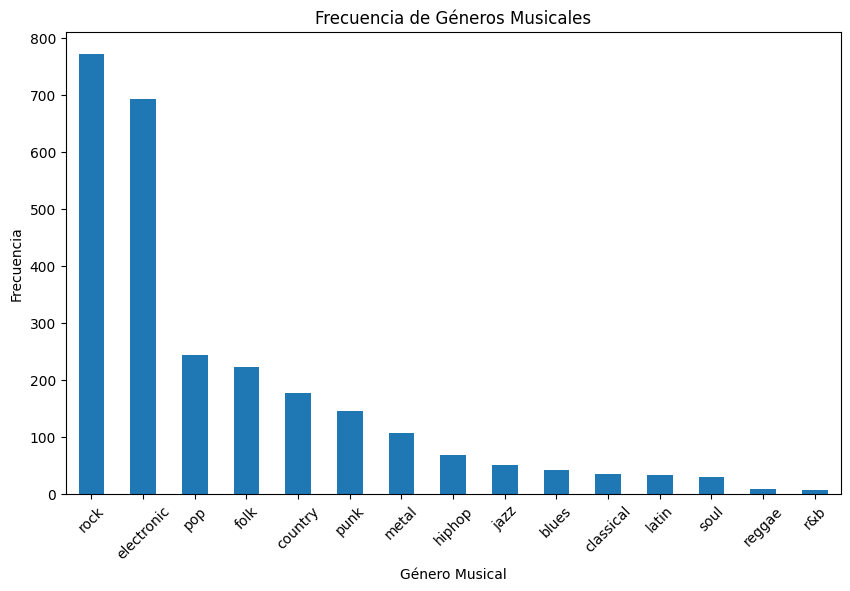

In [33]:
generos_musicales.plot(kind='bar', figsize=(10, 6))
plt.title('Frecuencia de Géneros Musicales')
plt.xlabel('Género Musical')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

In [5]:
df_artists

,artist_id,artist_name,genre
0,1000004,'Til Tuesday,electronic
1,1000006,.38 Special,pop
2,1000012,"10,000 Maniacs",metal
3,1000023,10cc,electronic
4,1000026,112,electronic
...,...,...,...
2626,1099513,The Darkness,metal
2627,1099605,The Sleepy Jackson,folk
2628,1099693,The Thrills,rock
2629,1100044,Beloved [US],pop


Tenemos un total de `2631` artistas distintos y solamente `15` géneros musicales diferentes. Los que tienen mayor frecuencia en nuestra bbdd es `rock`	con `773`, `electronic` con	`693`, `pop` con `244` y `folk`con	`222`. Los otros géneros musicales tienen menos de `200` observaciones, siendo los que tienen frecuencias menores los  géneros de `soul` con	`29`, `reggae` con	`8`y `r&b`	con `6`. Me llamó mucho la atención que `latin` también tenga poco más de 30 observaciones.

## Análisis del set de datos: `df_train_music`

Lo primero que realizaré es como ya está cargada la bbdd es ver la configuración de los datos y si tenemos algunos faltantes o transformaciones que puedan ser necesarias

In [3]:
df_train_music

,user_id,artist_id,rating
0,643947,1098682,62
1,784415,1068684,0
2,595120,1024523,100
3,1270239,1021824,0
4,735673,1019857,0
...,...,...,...
534632,1248788,1001649,0
534633,103798,1006535,0
534634,1248788,1013581,10
534635,1248788,1016358,14


In [6]:
df_train_music.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534637 entries, 0 to 534636
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    534637 non-null  int64
 1   artist_id  534637 non-null  int64
 2   rating     534637 non-null  int64
dtypes: int64(3)
memory usage: 12.2 MB


In [7]:
df_train_music.isnull().sum()

,0
user_id,0
artist_id,0
rating,0


Con esto confirmamos la cantidad de datos, tenemos id de usuarios, id de artistas y rating. Tenemos un total de 534637 por columna en el DF y no tenemos datos nulos en `df_train_music`



In [8]:
df_train_music.describe()

,user_id,artist_id,rating
count,5.346370e+05,5.346370e+05,534637.000000
mean,9.514221e+05,1.030821e+06,19.771927
std,5.609952e+05,2.839402e+04,34.829398
min,1.430000e+02,1.000004e+06,0.000000
25%,4.681470e+05,1.011139e+06,0.000000
50%,9.454190e+05,1.022601e+06,0.000000
75%,1.429002e+06,1.036736e+06,30.000000
max,1.948075e+06,1.100995e+06,255.000000


In [9]:
df_train_music['rating'].unique()

array([ 62,   0, 100,  40,  30,  56, 255,  70,  50,  59,  28,  46,  20,
        10,   2,  38,  90,  23,  78,  85,   1,  80,  21,  47,  72,   5,
        97,  60,  92,  48,  71,   4,   7,  32,  88,  67,  79,  83,   6,
        82,  39,   3,  19,  87,  69,   8,  74,  75,  84,  36,  89,  35,
        18,  45,  65,  22,  27,  15,  91,  16,  12,  43,  76,  26,  41,
        86,   9,  64,  49,  68,  95,  37,  58,  55,  96,  14,  13,  61,
        63,  53,  25,  24,  17,  34,  66,  73,  81,  52,  57,  42,  54,
        94,  44,  51,  31,  93,  77,  11,  98,  99,  29,  33])

In [11]:
rating_counts = df_train_music['rating'].value_counts().sort_index()
rating_counts

,count
rating,
0,334327
1,4530
2,1312
3,859
4,1112
...,...
97,127
98,428
99,169


In [12]:
534637 - 334327

200310

In [13]:
334327/534637

0.6253345728036032

In [16]:
numero_users = df_train_music['user_id'].nunique()
numero_users

2549

In [17]:
numero_artistas = df_train_music['artist_id'].nunique()
numero_artistas

2631

In [22]:
todos_artistas_ids = set(df_train_music['artist_id'].unique())

artistas_con_ratings = set(df_train_music['artist_id'].unique())

artistas_no_ratings = todos_artistas_ids - artistas_con_ratings

print(f"Total artistas en catálogo: {len(todos_artistas_ids)}")
print(f"Artistas con al menos una evaluación: {len(artistas_con_ratings)}")
print(f"Artistas sin NINGUNA evaluación: {len(artistas_no_ratings)}")

Total artistas en catálogo: 2631
Artistas con al menos una evaluación: 2631
Artistas sin NINGUNA evaluación: 0


In [24]:
todos_usuarios_ids = set(df_train_music['user_id'].unique())

usuarios_con_ratings = set(df_train_music['user_id'].unique())

usuarios_no_ratings = todos_usuarios_ids - usuarios_con_ratings

print(f"Total usuarios en catálogo: {len(todos_usuarios_ids)}")
print(f"Usuarios con al menos una evaluación: {len(usuarios_con_ratings)}")
print(f"Usuarios sin NINGUNA evaluación: {len(usuarios_no_ratings)}")

Total usuarios en catálogo: 2549
Usuarios con al menos una evaluación: 2549
Usuarios sin NINGUNA evaluación: 0


Los primeros análisis con `df_train_music.describe()`nos muestra que tenemos una gran cantidad de valores en cero, porque en `rating` los valores `min`, `25`y `50`están co valor 0
Luego con `df_train_music['rating'].value_counts().sort_index()`conté cuantos valores tenemos de cada rating único y nos podemos dar cuenta que el valor 0 efectivamente tiene un número importante, este es de un `62.5%` de los valores del dataframe `usuario`, `artista` y `rating`.
Este fenómeno de sparsity significativo es esperable, porque efectivamente los usuarios no consumen todo el catálogo.

El número de usuarios únicos es de 2549 y de artístas únicos es de 2631. De estos todos los artístas y usuarios tienen  evaluaciones.

In [25]:
artist_popularity = df_train_music['artist_id'].value_counts().reset_index()
artist_popularity.columns = ['artist_id', 'conteo_evaluaciones']

artist_popularity_named = artist_popularity.merge(df_artists, on='artist_id', how='left')

In [26]:
top_5_mas = artist_popularity_named.head(5)
print("Top 5 Artistas con MÁS evaluaciones")
print(top_5_mas[['artist_name', 'genre', 'conteo_evaluaciones']])

Top 5 Artistas con MÁS evaluaciones
           artist_name  genre  conteo_evaluaciones
0  Stone Temple Pilots   rock                  383
1         Eric Clapton   rock                  370
2            Foreigner   rock                  363
3            Metallica  metal                  361
4               Eagles   rock                  361


In [27]:
top_5_menos = artist_popularity_named.tail(5)
print("Top 5 Artistas con MENOS evaluaciones")
print(top_5_menos[['artist_name', 'genre', 'conteo_evaluaciones']])

Top 5 Artistas con MENOS evaluaciones
           artist_name       genre  conteo_evaluaciones
2626        Olga Tanon        folk                  103
2627              Snot  electronic                  103
2628  Neville Brothers        rock                  102
2629        Tom Lehrer        rock                  100
2630    Steve Ferguson        rock                   98


Con estos dos últimos códigos podemos ver que ningún artísta tiene más de 383 evaluaciones `Stone Temple Pilots` y ninguno menos de 98 `Steve Ferguson`

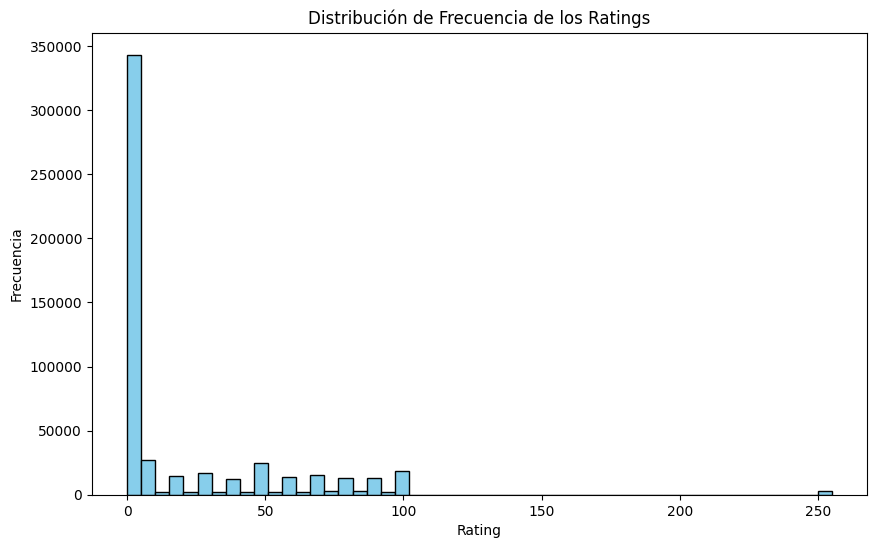

In [36]:
plt.figure(figsize=(10, 6))
plt.hist(df_train_music['rating'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de Frecuencia de los Ratings')
plt.xlabel('Rating')
plt.ylabel('Frecuencia')
plt.show()

In [40]:
print(np.sort(df_train_music['rating'].unique()))

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 255]


In [43]:
print((df_train_music['rating'] == 255).sum())

2759


In [45]:
print((df_train_music['rating'] == 100).sum())

17431


In [47]:
2759/534637

0.0051605107764707645

Con esto me di cuenta que tenemos un valor que parece atípico. Un `0.0051605107764707645%` de los valores tienen un valor 255 que creo no está bien porque el rating parece ser de 0 a 100. Por el momento no voy a tomar una decisión de qué hacer con esos datos, porque todavía no hago el análisis del `df_val_music`

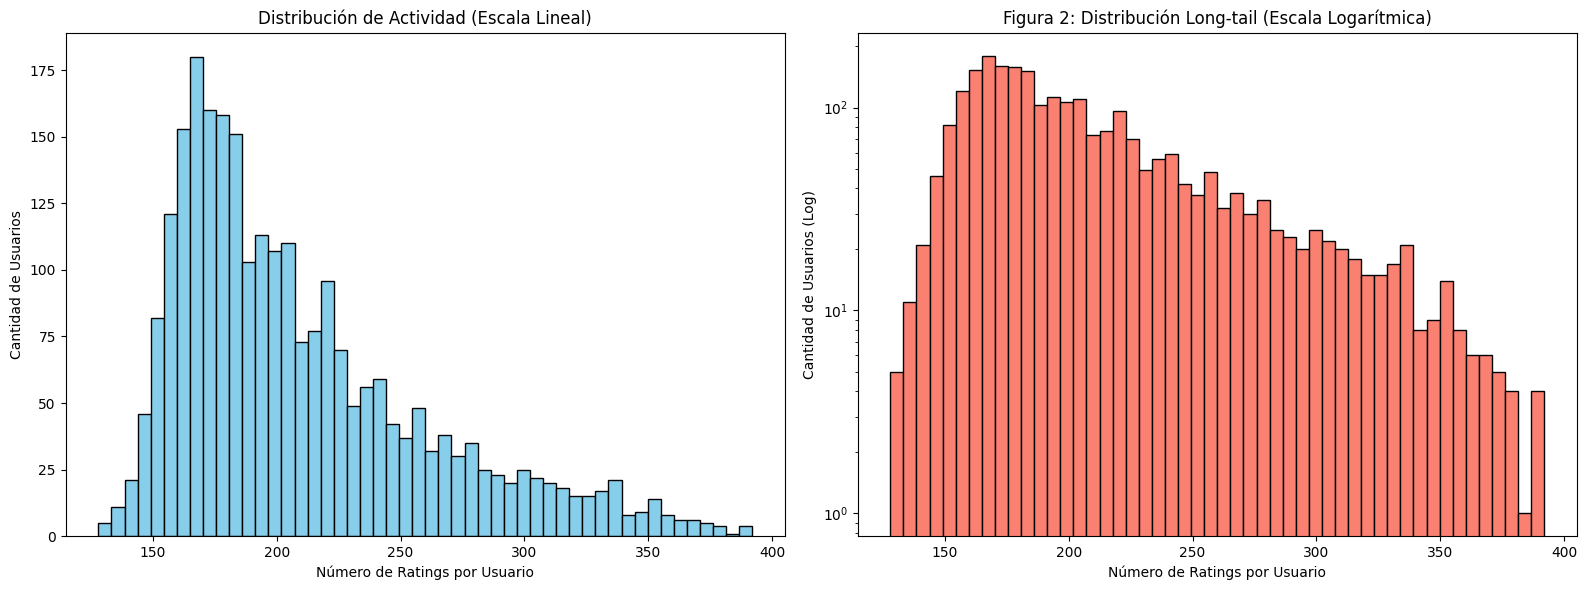

In [55]:
ratings_por_user = df_train_music['user_id'].value_counts()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.hist(ratings_por_user, bins=50, color='skyblue', edgecolor='black')
ax1.set_title('Distribución de Actividad (Escala Lineal)')
ax1.set_xlabel('Número de Ratings por Usuario')
ax1.set_ylabel('Cantidad de Usuarios')

ax2.hist(ratings_por_user, bins=50, color='salmon', edgecolor='black')
ax2.set_yscale('log')
ax2.set_title('Figura 2: Distribución Long-tail (Escala Logarítmica)')
ax2.set_xlabel('Número de Ratings por Usuario')
ax2.set_ylabel('Cantidad de Usuarios (Log)')

plt.tight_layout()
plt.show()

In [54]:
# Para la tabla de estadísticas
counts = df_train_music['user_id'].value_counts()

print(f"Promedio de ratings por usuario: {counts.mean():.2f}")
print(f"Máximo de ratings por un solo usuario: {counts.max()}")
print(f"Mínimo de ratings por un solo usuario: {counts.min()}")

Promedio de ratings por usuario: 209.74
Máximo de ratings por un solo usuario: 392
Mínimo de ratings por un solo usuario: 128


Este análisis nos demuestra que tenemos casi `210`evaluaciones promedio por usuarios, con un mínimo de `128`y un máximo de `392`evaluaciones por usuario. Por lo menos en este dataset no parece tener el problema de usuarios con muy pocos rating.

In [57]:
n_users_train = df_train_music['user_id'].nunique()
n_items_catalogo = df_artists['artist_id'].nunique()
n_ratings_train = len(df_train_music)

densidad_train = (n_ratings_train / (n_users_train * n_items_catalogo)) * 100

items_por_usuario = n_ratings_train / n_users_train

print(f"--- Análisis de Densidad: Entrenamiento ---")
print(f"Usuarios únicos: {n_users_train}")
print(f"Artistas en catálogo: {n_items_catalogo}")
print(f"Total de Ratings: {n_ratings_train}")
print(f"Promedio de artistas evaluados por usuario: {items_por_usuario:.2f}")
print(f"Densidad del Dataset: {densidad_train:.4f}%")

--- Análisis de Densidad: Entrenamiento ---
Usuarios únicos: 2549
Artistas en catálogo: 2631
Total de Ratings: 534637
Promedio de artistas evaluados por usuario: 209.74
Densidad del Dataset: 7.9720%


La densidad de nuestro set de entrenamiento es de `7.9720%` que indica que aunque la matriz es dispersa y tenemos un número importante de sparsity del `62.5%`.

## Análisis del set de datos: `df_val_music`

Como hice antes comenzaré a revisar la estructura de los datos y si tenemos datos faltantes

In [4]:
df_val_music

,user_id,artist_id,rating
0,1641538,1048320,0
1,1641538,1048942,53
2,1641538,1050886,30
3,930222,1098345,0
4,930222,1020250,0
...,...,...,...
152419,81478,1013119,50
152420,1922878,1009168,20
152421,1711362,1097521,100
152422,1692654,1004539,0
